In [57]:
from pathlib import Path
import pandas as pd

PROCESSED_DIR = Path("../data/processed")

#########
#Change yearly data to monthly
#########

def spread_yearly_data_to_months(file_path, year):
    df_year = pd.read_csv(file_path)

    # Datum may already exist in the yearly file.
    # Remove it because we create new monthly dates below.
    if "Datum" in df_year.columns:
        df_year = df_year.drop(columns=["Datum"])

    month_ends = pd.date_range(
        start=f"{year}-01-01",
        end=f"{year}-12-31",
        freq="ME"
    )

    id_cols = ["Bundesland", "Fahrzeugklasse"]

    value_cols = [
        c for c in df_year.columns
        if c not in id_cols
    ]

    df_year[value_cols] = df_year[value_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    df_year_monthly_values = df_year.copy()
    df_year_monthly_values[value_cols] = df_year_monthly_values[value_cols] / 12

    monthly_dfs = []

    for date in month_ends:
        df_month = df_year_monthly_values.copy()
        df_month["Datum"] = date
        monthly_dfs.append(df_month)

    df_monthly = pd.concat(monthly_dfs, ignore_index=True)

    df_monthly = df_monthly[
        ["Datum", "Bundesland", "Fahrzeugklasse"] + value_cols
    ]

    return df_monthly
file_2024 = PROCESSED_DIR / "ev_registrations_clean_2024.csv"
file_2025 = PROCESSED_DIR / "ev_registrations_clean_2025.csv"

df_2024_monthly = spread_yearly_data_to_months(file_2024, 2024)
df_2025_monthly = spread_yearly_data_to_months(file_2025, 2025)

output_path = PROCESSED_DIR / "ev_registrations_yearly_spread_monthly.csv"

output_path = PROCESSED_DIR / "ev_registrations_clean_2025_monthly.csv"

df_2025_monthly.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("File exists:", output_path.exists())

df_check = pd.read_csv(output_path)

display(df_check.head())
display(df_check.tail())
print(df_check.shape)
print(df_check.dtypes)


Saved to: ../data/processed/ev_registrations_clean_2025_monthly.csv
File exists: True


,Datum,Bundesland,Fahrzeugklasse,Benzin inkl.Flex-Fuel,Diesel,Elektro,Flüssiggas,Erdgas,Benzin/Flüssiggas (bivalent),Benzin/Erdgas (bivalent),Benzin/Elektro (hybrid),Diesel/Elektro (hybrid),Wasserstoff(Brennstoffzelle)
0,2025-01-31,Österreich,All,10164.250000,6459.833333,5791.583333,1.166667,0.25,0.500000,1.166667,8157.666667,1244.25,1.0
1,2025-01-31,Österreich,Personenkraftwagen Klasse M1,6621.416667,2750.333333,5054.250000,NaN,NaN,0.166667,NaN,8095.250000,1226.75,NaN
2,2025-01-31,Österreich,Motorräder Klasse L3e,2561.416667,NaN,109.666667,NaN,NaN,NaN,NaN,0.666667,NaN,NaN
3,2025-01-31,Österreich,Motorfahrräder Klasse L1e,669.250000,NaN,98.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-31,Österreich,Vierrädrige Kraftfahrzeuge Klasse L7e,1.000000,NaN,6.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Datum,Bundesland,Fahrzeugklasse,Benzin inkl.Flex-Fuel,Diesel,Elektro,Flüssiggas,Erdgas,Benzin/Flüssiggas (bivalent),Benzin/Erdgas (bivalent),Benzin/Elektro (hybrid),Diesel/Elektro (hybrid),Wasserstoff(Brennstoffzelle)
2275,2025-12-31,Wien,Motor- und Transportkarren,NaN,2.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2276,2025-12-31,Wien,Selbstfahrende Arbeitsmaschinen,NaN,16.416667,0.916667,NaN,NaN,NaN,NaN,NaN,NaN,0.083333
2277,2025-12-31,Wien,Erntemaschinen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2278,2025-12-31,Wien,Wohnmobile,0.083333,9.000000,NaN,NaN,NaN,NaN,NaN,0.25,NaN,NaN
2279,2025-12-31,Wien,Sonstige Kraftfahrzeuge,NaN,5.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(2280, 13)
Datum                               str
Bundesland                          str
Fahrzeugklasse                      str
Benzin inkl.Flex-Fuel           float64
Diesel                          float64
Elektro                         float64
Flüssiggas                      float64
Erdgas                          float64
Benzin/Flüssiggas (bivalent)    float64
Benzin/Erdgas (bivalent)        float64
Benzin/Elektro (hybrid)         float64
Diesel/Elektro (hybrid)         float64
Wasserstoff(Brennstoffzelle)    float64
dtype: object


In [59]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


PROCESSED_DIR = Path("../data/processed")
OUTPUT_FILE = PROCESSED_DIR / "ev_registrations_monthly.csv"

#######
# Inspect Files
######

def main():
    csv_files = sorted(
        file for file in PROCESSED_DIR.glob("*.csv")
        if file.name != OUTPUT_FILE.name
    )

    if not csv_files:
        raise FileNotFoundError("No CSV files found in data/processed/")

    print(f"Found {len(csv_files)} CSV files:")
    for i, file in enumerate(csv_files):
        print(f"{i}: {file.name}")

    # Allow user to choose which files to use
    selected_indices = input("Enter the indices of the files to combine (comma-separated, e.g., 0,1,2): ")
    selected_indices = [int(x.strip()) for x in selected_indices.split(',') if x.strip().isdigit()]
    selected_files = [csv_files[i] for i in selected_indices if i < len(csv_files)]

    if not selected_files:
        print("No valid files selected.")
        return

    print(f"Selected {len(selected_files)} files:")
    for file in selected_files:
        print(f"- {file.name}")

    dataframes = []

    for file in selected_files:
        df = pd.read_csv(file)

        # Keep track of the original file
        df["source_file"] = file.name

        dataframes.append(df)

    combined = pd.concat(dataframes, ignore_index=True, sort=False)

    combined.to_csv(OUTPUT_FILE, index=False)

    print()
    print(f"Saved combined file to: {OUTPUT_FILE}")
    print(f"Combined shape: {combined.shape}")
    print()
    print("Columns:")
    for col in combined.columns:
        print(f"- {col}")


if __name__ == "__main__":
    main()


########
# Mapping
########   

EV_COLUMNS = [
    "Elektro",
    "Wasserstoff(Brennstoffzelle)",
]

FOSSIL_COLUMNS = [
    "Benzin",
    "Diesel",
    "Flüssiggas",
    "Erdgas",
    "Benzin/Flüssiggas (bivalent)",
    "Benzin/Erdgas (bivalent)",
    "Benzin inkl.Flex-Fuel",
]

HYBRID_COLUMNS = [
    "Benzin/Elektro (hybrid)",
    "Diesel/Elektro (hybrid)",
]

fuel_columns = EV_COLUMNS + FOSSIL_COLUMNS + HYBRID_COLUMNS



Found 7 CSV files:
0: ev_registrations_clean_2024.csv
1: ev_registrations_clean_2024_monthly.csv
2: ev_registrations_clean_2025.csv
3: ev_registrations_clean_2025_monthly.csv
4: ev_registrations_clean_2026_01.csv
5: ev_registrations_clean_2026_02.csv
6: ev_registrations_clean_2026_03.csv
Selected 5 files:
- ev_registrations_clean_2024_monthly.csv
- ev_registrations_clean_2025_monthly.csv
- ev_registrations_clean_2026_01.csv
- ev_registrations_clean_2026_02.csv
- ev_registrations_clean_2026_03.csv

Saved combined file to: ../data/processed/ev_registrations_monthly.csv
Combined shape: (5130, 15)

Columns:
- Datum
- Bundesland
- Fahrzeugklasse
- Benzin
- Diesel
- Elektro
- Flüssiggas
- Erdgas
- Benzin/Flüssiggas (bivalent)
- Benzin/Erdgas (bivalent)
- Benzin/Elektro (hybrid)
- Diesel/Elektro (hybrid)
- Wasserstoff(Brennstoffzelle)
- source_file
- Benzin inkl.Flex-Fuel


In [60]:

INPUT_FILE = Path("../data/processed/ev_registrations_monthly.csv")
df = pd.read_csv(INPUT_FILE)



new_registrations_all = df[
    (df["Bundesland"] == "Österreich") &
    (df["Fahrzeugklasse"] == "All")
]

fuel_columns = EV_COLUMNS + FOSSIL_COLUMNS + HYBRID_COLUMNS

#display(new_registrations_all.head(10))

new_registrations_all["Datum"] = pd.to_datetime(new_registrations_all["Datum"], errors="raise")
new_registrations_all["month"] = new_registrations_all["Datum"].dt.to_period("M").astype(str)

new_registrations_all["electric_new_registrations"] = new_registrations_all[EV_COLUMNS].sum(axis=1)
new_registrations_all["fossil_new_registrations"] = new_registrations_all[FOSSIL_COLUMNS].sum(axis=1)
new_registrations_all["hybrid_new_registrations"] = new_registrations_all[HYBRID_COLUMNS].sum(axis=1)

new_registrations_all["total_new_registrations"] = (
    new_registrations_all["electric_new_registrations"]
    + new_registrations_all["fossil_new_registrations"]
    + new_registrations_all["hybrid_new_registrations"]
)

#display(df.head(10))
display(new_registrations_all["electric_new_registrations"].head(10))



0       4306.083333
190     4306.083333
380     4306.083333
570     4306.083333
760     4306.083333
950     4306.083333
1140    4306.083333
1330    4306.083333
1520    4306.083333
1710    4306.083333
Name: electric_new_registrations, dtype: float64

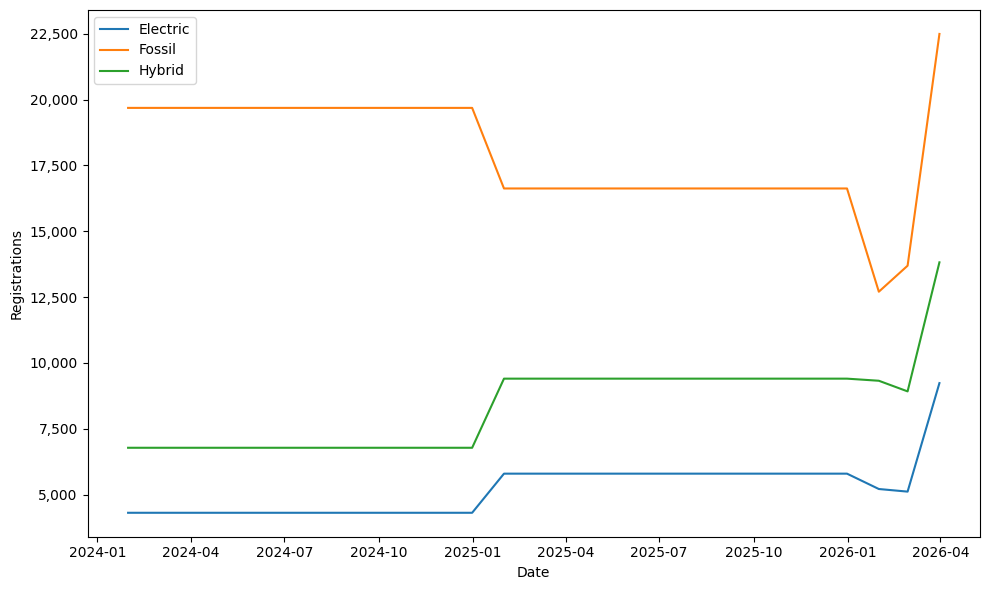

In [61]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    new_registrations_all["Datum"],
    new_registrations_all["electric_new_registrations"],
    label="Electric",
)

ax.plot(
    new_registrations_all["Datum"],
    new_registrations_all["fossil_new_registrations"],
    label="Fossil",
)

ax.plot(
    new_registrations_all["Datum"],
    new_registrations_all["hybrid_new_registrations"],
    label="Hybrid",
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.set_xlabel("Date")
ax.set_ylabel("Registrations")
ax.legend()

plt.tight_layout()
plt.show()